In [1]:
#!/user/bin/env python 3
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from transformers import Pipeline
from sklearn.model_selection import GridSearchCV #网格搜索
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid',font_scale=1.3)
plt.rcParams['font.family']='SimHei'
plt.rcParams['axes.unicode_minus']=False
import sklearn
from sklearn import preprocessing                            #数据预处理模块
from sklearn.preprocessing import LabelEncoder               #编码转换
from sklearn.preprocessing import StandardScaler             #归一化
from sklearn.model_selection import StratifiedShuffleSplit   #分层抽样
from sklearn.model_selection import train_test_split         #数据分区
from sklearn.decomposition import PCA                        #主成分分析 （降维）
from sklearn.ensemble import RandomForestClassifier     #随机森林
from sklearn.svm import SVC,LinearSVC                   #支持向量机
from sklearn.linear_model import LogisticRegression     #逻辑回归
from sklearn.neighbors import KNeighborsClassifier      #KNN算法
from sklearn.cluster import KMeans                     #K-Means 聚类算法
from sklearn.naive_bayes import GaussianNB              #朴素贝叶斯
from sklearn.tree import DecisionTreeClassifier         #决策树
import xgboost as xgb
from xgboost import XGBClassifier                      
from catboost import CatBoostClassifier                
from sklearn.ensemble import AdaBoostClassifier        
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score  #分类报告
from sklearn.metrics import confusion_matrix           #混淆矩阵
from sklearn.metrics import silhouette_score           #轮廓系数（评价k-mean聚类效果）
from sklearn.model_selection import GridSearchCV       #交叉验证
from sklearn.metrics import make_scorer
from sklearn.ensemble import VotingClassifier          #投票
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats

In [2]:
f=open('D:/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data = pd.read_csv(f)

print('源数据类型:',data.dtypes)
print('源数据shape:',data.shape)
data.info()

源数据类型: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
源数据shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 

In [3]:
# 数据清洗
#保证数据完整性先备份数据
data_cp = data.copy()

#重复值处理
data_cp = data_cp.drop_duplicates(['customerID'])
print('去重后，数据shape:',data_cp.shape)

data_cp.info()

去重后，数据shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

In [4]:
#检查是否有nan值
print(data_cp.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
#检查是否有空字符串
l=[]
for index,row in data_cp.iterrows():
    if len(row['TotalCharges'].strip())==0:
        l.append(index)
print(data_cp.loc[l,['customerID','gender','tenure','MonthlyCharges','TotalCharges']])

      customerID  gender  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI  Female       0           52.55             
753   3115-CZMZD    Male       0           20.25             
936   5709-LVOEQ  Female       0           80.85             
1082  4367-NUYAO    Male       0           25.75             
1340  1371-DWPAZ  Female       0           56.05             
3331  7644-OMVMY    Male       0           19.85             
3826  3213-VVOLG    Male       0           25.35             
4380  2520-SGTTA  Female       0           20.00             
5218  2923-ARZLG    Male       0           19.70             
6670  4075-WKNIU  Female       0           73.35             
6754  2775-SEFEE    Male       0           61.90             


In [6]:
# 留存月份改为1，总计缴费改为一个月的月缴费用
for index,row in data_cp.iterrows():
    if len(row['TotalCharges'].strip())==0:
        # row['tenure']=1
        # row['TotalCharges']=row['MonthlyCharges']
        data_cp.loc[index,'tenure']=1
        data_cp.loc[index,'TotalCharges']=row['MonthlyCharges']

In [7]:
data_cp['TotalCharges']=data_cp['TotalCharges'].astype(float)

In [8]:
print(data_cp.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.372710       64.761692   2279.798992
std         0.368612    24.557454       30.090047   2266.730170
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


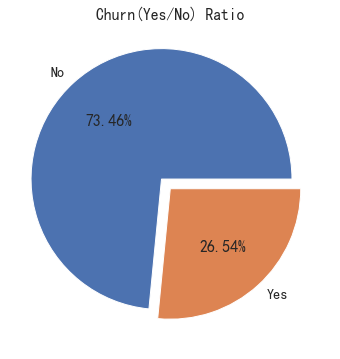

In [9]:
#保存图片自定义函数
def savePic(name):
#bounding box_inches(边框英寸)设置，保存的图片去掉周围空白
    plt.savefig('D:/{0}.png'.format(name), dpi=600,bbox_inches='tight')

plt.rcParams['figure.figsize']=6,6
plt.pie(data_cp['Churn'].value_counts(),labels=data_cp['Churn'].value_counts().index,autopct='%1.2f%%',explode=(0.1,0))
plt.title('Churn(Yes/No) Ratio')
savePic('Churn(Yes or No) Ratio')
plt.show()

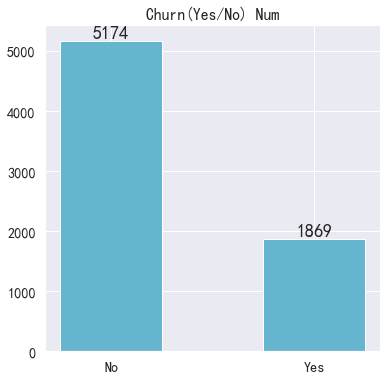

In [10]:
churnDf=data_cp['Churn'].value_counts().to_frame()
x=churnDf.index
y=churnDf['Churn']
plt.bar(x,y,width = 0.5,color = 'c')

#用来正常显示中文标签（需要安装字库）
plt.rcParams['font.sans-serif']=['SimHei'] 
plt.rcParams.update({'font.size': 18})
plt.title('Churn(Yes/No) Num')
for a,b in zip(x,y):
    plt.text(a,b+10,'%.0f' % b, ha='center', va= 'bottom')
savePic('Churn(Yes or No) Num')
plt.show()

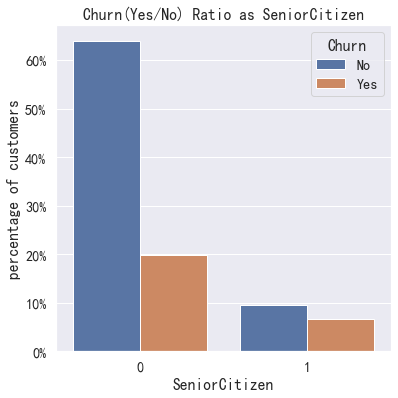

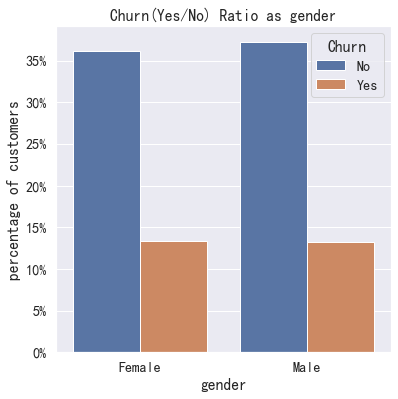

In [11]:
def barplot_percentages(feature,orient='v',axis_name="percentage of customers"):
    ratios = pd.DataFrame()
    g = (data_cp.groupby(feature)["Churn"].value_counts()/len(data_cp)).to_frame()
    g.rename(columns={"Churn":axis_name},inplace=True)
    g.reset_index(inplace=True)

    #print(g)
    if orient == 'v':
        ax = sns.barplot(x=feature, y= axis_name, hue='Churn', data=g, orient=orient)
        ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()])
        plt.rcParams.update({'font.size': 13})
        #plt.legend(fontsize=10)
    else:
        ax = sns.barplot(x= axis_name, y=feature, hue='Churn', data=g, orient=orient)
        ax.set_xticklabels(['{:,.0%}'.format(x) for x in ax.get_xticks()])
        plt.legend(fontsize=10)
    plt.title('Churn(Yes/No) Ratio as {0}'.format(feature))
    savePic('Churn(Yes or No) Ratio as {0}'.format(feature))
    plt.show()
barplot_percentages("SeniorCitizen")
barplot_percentages("gender")

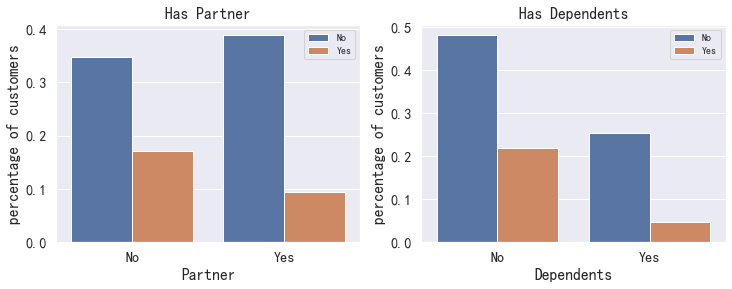

In [12]:
fig, axis = plt.subplots(1, 2, figsize=(12,4))
axis[0].set_title("Has Partner")
axis[1].set_title("Has Dependents")
axis_y = "percentage of customers"

# Plot Partner column
gp_partner = (data_cp.groupby('Partner')["Churn"].value_counts()/len(data_cp)).to_frame()
gp_partner.rename(columns={"Churn": axis_y}, inplace=True)
gp_partner.reset_index(inplace=True)
ax1 = sns.barplot(x='Partner', y= axis_y, hue='Churn', data=gp_partner, ax=axis[0])
ax1.legend(fontsize=10)
#ax1.set_xlabel('伴侣')


# Plot Dependents column
gp_dep = (data_cp.groupby('Dependents')["Churn"].value_counts()/len(data_cp)).to_frame()
#print(gp_dep)
gp_dep.rename(columns={"Churn": axis_y} , inplace=True)
#print(gp_dep)
gp_dep.reset_index(inplace=True)
#print(gp_dep)

ax2 = sns.barplot(x='Dependents', y= axis_y, hue='Churn', data=gp_dep, ax=axis[1])
#ax2.set_xlabel('家属')


#设置字体大小
plt.rcParams.update({'font.size': 20})
ax2.legend(fontsize=10)

#设置
savePic('Churn(Yes or No) Ratio as partner and dependents')
plt.show()

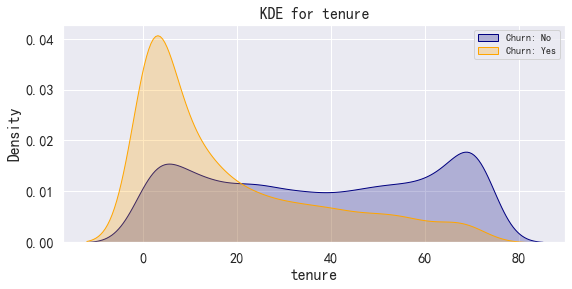

In [13]:
# Kernel density estimaton核密度估计
def kdeplot(feature,xlabel):
    plt.figure(figsize=(9, 4))
    plt.title("KDE for {0}".format(feature))
    ax0 = sns.kdeplot(data_cp[data_cp['Churn'] == 'No'][feature].dropna(), color= 'navy', label= 'Churn: No', shade='True')
    ax1 = sns.kdeplot(data_cp[data_cp['Churn'] == 'Yes'][feature].dropna(), color= 'orange', label= 'Churn: Yes',shade='True')
    plt.xlabel(xlabel)
    #设置字体大小
    plt.rcParams.update({'font.size': 20})
    plt.legend(fontsize=10)
kdeplot('tenure','tenure')
savePic('Churn(Yes or No) Ratio as tenure kde')
plt.show()

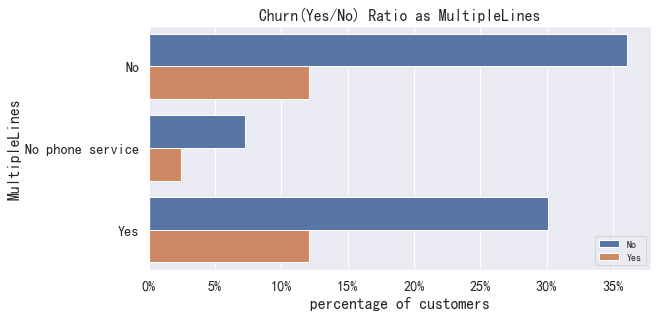

In [14]:
plt.figure(figsize=(9, 4.5))
barplot_percentages("MultipleLines", orient='h')

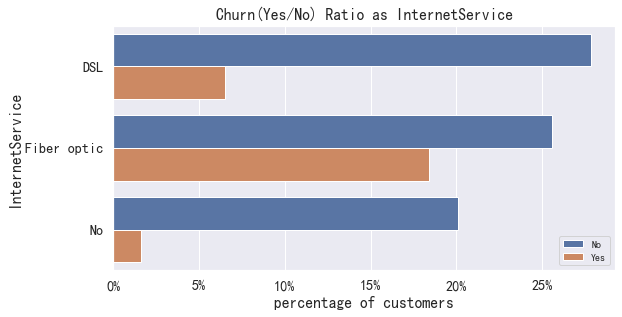

In [15]:
plt.figure(figsize=(9, 4.5))
barplot_percentages("InternetService", orient="h")

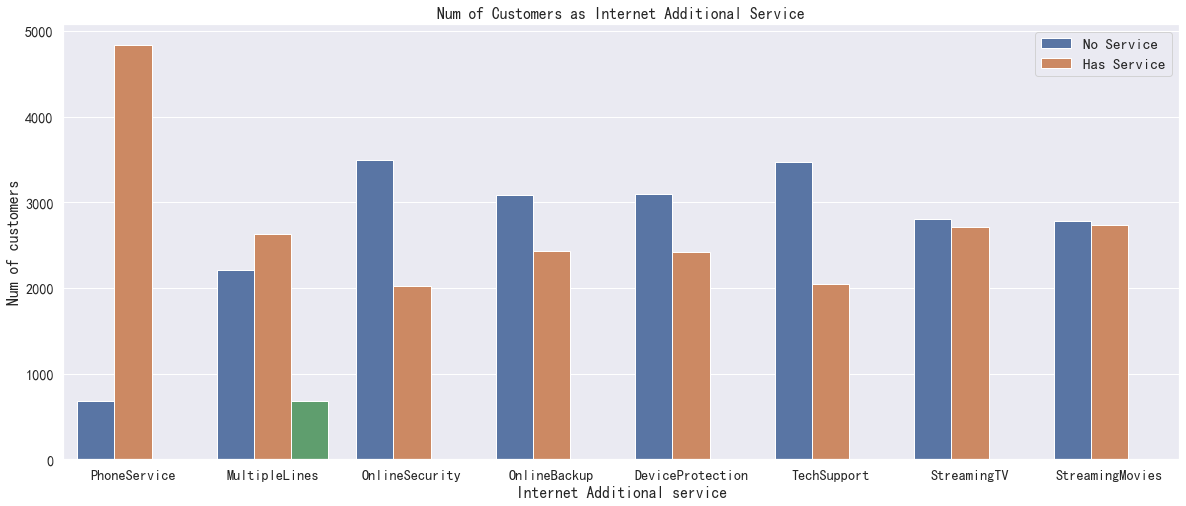

In [16]:
cols = ["PhoneService","MultipleLines","OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df1 = pd.melt(data_cp[data_cp["InternetService"] != "No"][cols])
df1.rename(columns={'value': 'Has service'},inplace=True)
plt.figure(figsize=(20, 8))
ax = sns.countplot(data=df1, x='variable', hue='Has service')
ax.set(xlabel='Internet Additional service', ylabel='Num of customers')
plt.rcParams.update({'font.size':20})
plt.legend( labels = ['No Service', 'Has Service'],fontsize=15)
plt.title('Num of Customers as Internet Additional Service')
savePic('Churn(Yes or No) Num as Internet Additional Service')
plt.show()

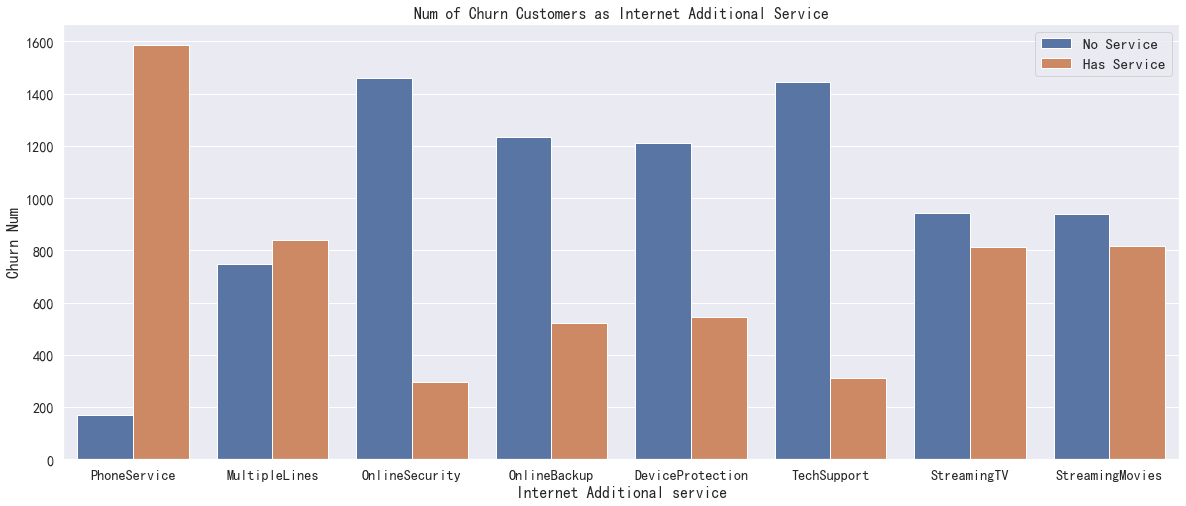

In [17]:
plt.figure(figsize=(20, 8))
df1 = data_cp[(data_cp.InternetService != "No") & (data_cp.Churn == "Yes")]
df1 = pd.melt(df1[cols])
df1.rename(columns={'value': 'Has service'}, inplace=True)
ax = sns.countplot(data=df1, x='variable', hue='Has service', hue_order=['No', 'Yes'])
ax.set(xlabel='Internet Additional service', ylabel='Churn Num')
plt.rcParams.update({'font.size':20})
plt.legend( labels = ['No Service', 'Has Service'],fontsize=15)
plt.title('Num of Churn Customers as Internet Additional Service')
savePic('Churn Num as Internet Additional Service')
plt.show()

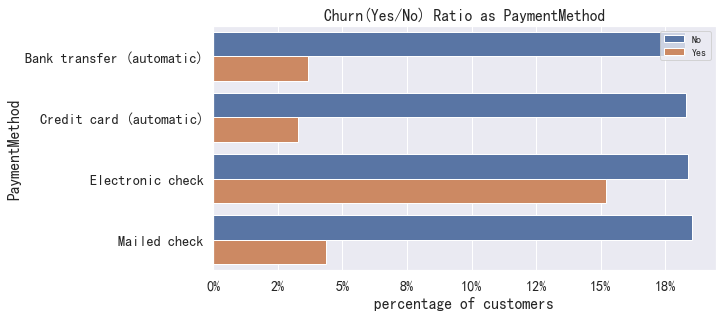

In [18]:
plt.figure(figsize=(9, 4.5))
barplot_percentages("PaymentMethod",orient='h')

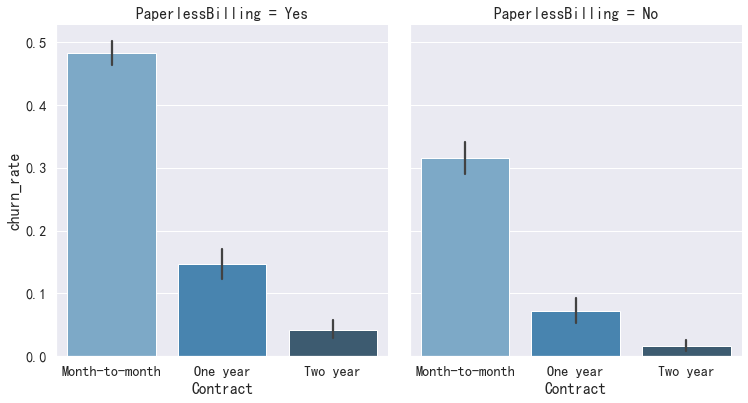

In [19]:
data_cp['churn_rate'] = data_cp['Churn'].replace("No", 0).replace("Yes", 1)
g = sns.FacetGrid(data_cp, col="PaperlessBilling", height=6, aspect=.9)
ax = g.map(sns.barplot, "Contract", "churn_rate", palette = "Blues_d", order= ['Month-to-month', 'One year', 'Two year'])
plt.rcParams.update({'font.size':18})
savePic('Churn Ratio as PaperlessBilling')
plt.show()


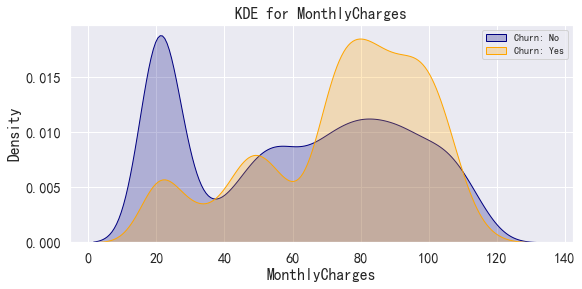

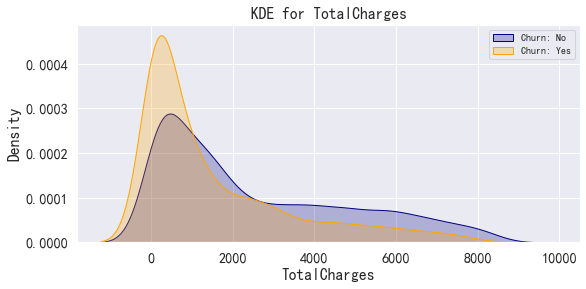

In [20]:
kdeplot('MonthlyCharges','MonthlyCharges')
savePic('Churn(Yes or No) Ratio as MonthlyCharges kde')
kdeplot('TotalCharges','TotalCharges')
savePic('Churn(Yes or No) Ratio as TotalCharges kde')
plt.show()


In [21]:
customerID=data_cp['customerID']
data_cp.drop(['customerID'],axis=1, inplace=True)

In [22]:
cateCols = [c for c in data_cp.columns if data_cp[c].dtype == 'object' or c == 'SeniorCitizen']
dfCate = data_cp[cateCols].copy()
dfCate.head(3)


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [23]:
for col in cateCols:
    if dfCate[col].nunique() == 2:
        dfCate[col] = pd.factorize(dfCate[col])[0]
    else:
        dfCate = pd.get_dummies(dfCate, columns=[col])
dfCate['tenure']=data_cp[['tenure']]
dfCate['MonthlyCharges']=data_cp[['MonthlyCharges']]
dfCate['TotalCharges']=data_cp[['TotalCharges']]

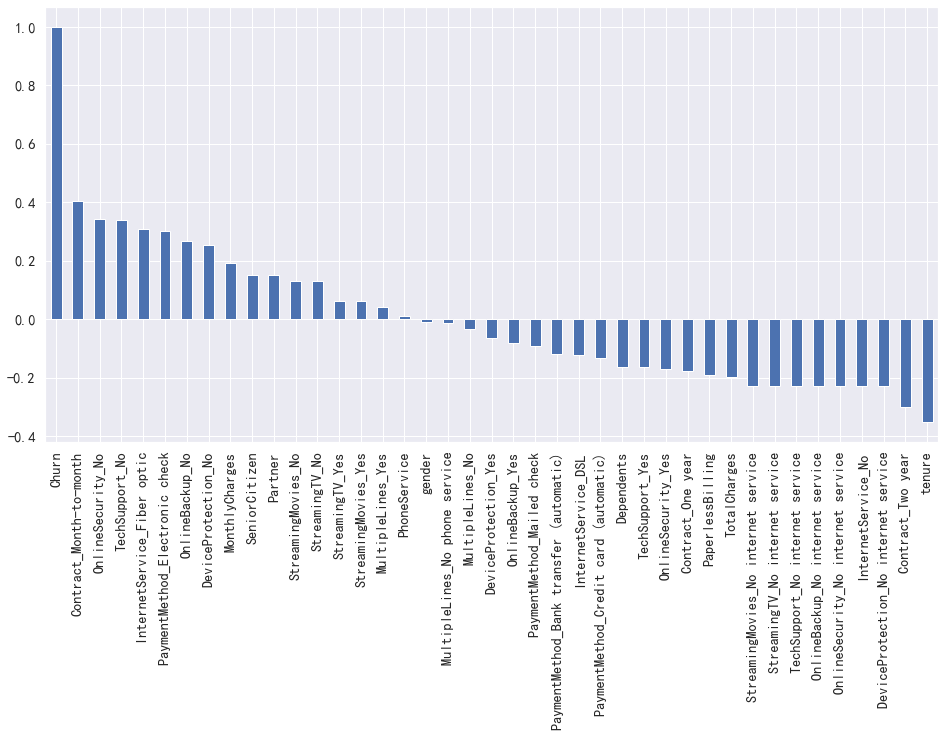

In [24]:
plt.figure(figsize=(16,8))
dfCate.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [25]:
data_cpvar=data_cp.iloc[:,2:20]
data_cpvar.drop('PhoneService',axis=1,inplace=True)

#提取ID
data_cp_id=data_cp['Churn']
print(data_cpvar.head())


  Partner Dependents  tenure     MultipleLines InternetService OnlineSecurity  \
0     Yes         No       1  No phone service             DSL             No   
1      No         No      34                No             DSL            Yes   
2      No         No       2                No             DSL            Yes   
3      No         No      45  No phone service             DSL            Yes   
4      No         No       2                No     Fiber optic             No   

  OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies  \
0          Yes               No          No          No              No   
1           No              Yes          No          No              No   
2          Yes               No          No          No              No   
3           No              Yes         Yes          No              No   
4           No               No          No          No              No   

         Contract PaperlessBilling              PaymentMethod 

In [26]:

#模型特征构建
data_model = data_cp.copy()
# 合并特征，business1,2,3

data_model['business1'] = data_model.apply(lambda x:1 if (x.OnlineSecurity =='Yes')&(x.TechSupport == 'Yes') else 0 , axis =1)
data_model['business2'] = data_model.apply(lambda x:1 if (x.DeviceProtection =='Yes')&(x.OnlineBackup == 'Yes') else 0   , axis =1)
data_model['business3'] = data_model.apply(lambda x:1 if (x.StreamingTV =='Yes')&(x.StreamingMovies == 'Yes') else 0   , axis =1)

#对tenure、MonthlyCharges 分桶 根据之前分析 MonthlyCharges 分为4个bins,tenure分为3个bins
data_model['MonthlyCharges_bins'] = pd.cut(data_model['MonthlyCharges'],4)
data_model['tenure_bins'] = pd.cut(data_model['tenure'],3)

#独热编码
data_model['SeniorCitizen'] = data_model['SeniorCitizen'].astype(str)

data_model['alone'] = data_model.apply(lambda x:1 if (x.Partner == 'No')&(x.Dependents == 'No') else 0 , axis = 1)
# data_model['alone'] = data_model['alone'].astype(str)
data_model['business1'] = data_model['business1'].astype(str)
data_model['business2'] = data_model['business2'].astype(str)
data_model['business3'] = data_model['business3'].astype(str)
data_model['MultipleLines'] = data_model['MultipleLines'].apply(lambda x :1 if x=='Yes' else 0)
data_model['MultipleLines'] = data_model['MultipleLines'].astype(str)
x = data_model[['Partner','Dependents','alone','Contract','business1','business2','business3','tenure_bins','MonthlyCharges_bins','PaymentMethod','PaperlessBilling']]
target = data_model['Churn'].apply(lambda x:1 if x =='Yes' else 0 )
x = pd.get_dummies(x)

In [36]:
# 划分数据集，用留出法取4/5的数据用于训练，1/5用于检测
from sklearn.model_selection import train_test_split

x_train, x_test, target_train, target_test = train_test_split(x, target, test_size=0.25, random_state=0)
# 构建模型
# 导入算法模块
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import make_scorer, accuracy_score

#将需要使用的模型及需要网格搜索的参数提前设定
# LogisticRegression
LR_clf = LogisticRegression(max_iter= 3000)
param_dict1 = {
    'penalty' : ['l1','l2'],
    'C':[5,10,12,14],
    'class_weight':['balanced']
    
}
# DecisionTreeClassifier
DT_clf = DecisionTreeClassifier(random_state=0)
param_dict2 = {
    'max_depth':[4,5,6],
    'min_samples_leaf' : [1,2,3],
    'class_weight':['balanced']
}
# MultinomialNB
NBC_clf = MultinomialNB()
para_dict3 ={
    'alpha' : [1.0]
}
# SVC
SVC_clf = SVC()
param_dict4 = {
    'C':[1,2,3,4],
    'kernel':['rbf','linear','poly'],
    'class_weight':['balanced']
}
# RandomForestClassifier
RF_clf = RandomForestClassifier()
param_dict5 = {
    'n_estimators' :range(80,200,4),
    'max_features':[2,4,6,8],
    'class_weight':['balanced']
}
# KNeighborsClassifier
KNN_clf = KNeighborsClassifier()
param_dict6 = {
    'n_neighbors':[5]
}

Model_list = [LR_clf,DT_clf,NBC_clf,SVC_clf,RF_clf,KNN_clf]
param_list = [param_dict1,param_dict2,para_dict3,param_dict4,param_dict5,param_dict6]
estimator = []
params = []
score = []
scoring = make_scorer(recall_score)
for i in range(6):
    clf_R = Model_list[i]
    parameters = param_list[i]
    grid = GridSearchCV(clf_R,parameters,cv = 5,scoring= scoring,n_jobs = -1)
    grid.fit(x_train,target_train)
    temp = grid.best_estimator_
    estimator.append(temp)
    temp = grid.best_params_
    params.append(temp)
    temp = grid.best_score_
    score.append(temp)
    
for i in range(6):
    model = estimator[i]
    model.fit(x_train,target_train)
    y_predict = model.predict(x_test)
    recall = recall_score(y_true=target_test,y_pred=y_predict)
    print('算法模型：',estimator[i],'\n')
    print('模型参数：',params[i],'\n')
    print('模型的召回率：',recall,'\n')
    print('模型测试精确率：',score[i],'\n')
    print('-'*20)

算法模型： LogisticRegression(C=5, class_weight='balanced', max_iter=3000) 

模型参数： {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2'} 

模型的召回率： 0.7710583153347732 

模型测试精确率： 0.8044143257363519 

--------------------
算法模型： DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=0) 

模型参数： {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1} 

模型的召回率： 0.7494600431965442 

模型测试精确率： 0.7930289492945659 

--------------------
算法模型： MultinomialNB() 

模型参数： {'alpha': 1.0} 

模型的召回率： 0.6479481641468683 

模型测试精确率： 0.6842053456500341 

--------------------
算法模型： SVC(C=1, class_weight='balanced', kernel='linear') 

模型参数： {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'} 

模型的召回率： 0.8552915766738661 

模型测试精确率： 0.8954519068170921 

--------------------
算法模型： RandomForestClassifier(class_weight='balanced', max_features=6,
                       n_estimators=104) 

模型参数： {'class_weight': 'balanced', 'max_features': 6, 'n_estimators': 104} 

模型的召回率： 0.69978401727861

In [37]:
# 遍历最佳模型列表
for i in range(6):
    # 使用最佳模型进行预测
    best_model = estimator[i]
    y_predict = best_model.predict(x_train.tail(10))
    # 打印模型信息
    
    print(f'使用 {type(best_model).__name__} 模型的预测结果：\n{y_predict}\n{"-" * 20}')
    

使用 LogisticRegression 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 DecisionTreeClassifier 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 MultinomialNB 模型的预测结果：
[1 0 0 0 0 1 1 0 1 0]
--------------------
使用 SVC 模型的预测结果：
[1 0 0 1 0 1 1 0 1 1]
--------------------
使用 RandomForestClassifier 模型的预测结果：
[1 0 0 1 0 1 1 0 1 0]
--------------------
使用 KNeighborsClassifier 模型的预测结果：
[1 0 0 0 0 1 0 0 1 0]
--------------------


In [33]:
x_train.tail(10)

,alone,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,business1_0,business1_1,...,"MonthlyCharges_bins_(18.15, 43.375]","MonthlyCharges_bins_(43.375, 68.5]","MonthlyCharges_bins_(68.5, 93.625]","MonthlyCharges_bins_(93.625, 118.75]",PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaperlessBilling_No,PaperlessBilling_Yes
5874,1,1,0,1,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4373,0,0,1,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,1,1,0
1033,0,0,1,1,0,0,0,1,1,0,...,1,0,0,0,1,0,0,0,1,0
5827,0,0,1,0,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1
4859,0,0,1,1,0,0,0,1,1,0,...,0,0,0,1,0,1,0,0,1,0
4931,0,0,1,1,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
3264,0,1,0,0,1,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
1653,0,0,1,1,0,0,0,1,1,0,...,1,0,0,0,0,0,0,1,1,0
2607,1,1,0,1,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
2732,0,1,0,0,1,1,0,0,1,0,...,1,0,0,0,0,1,0,0,1,0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the features and target
X = data_cp.drop(['Churn', 'customerID'], axis=1)
y = data_cp['Churn']

# Define the numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define the preprocessing steps
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

# Combine the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Fit and transform the data
X_preprocessed = preprocessor.fit_transform(X)

# Encode the target variable
y_encoded = le.fit_transform(y)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=0)

X_train.shape, X_test.shape

NameError: name 'le' is not defined